# Preprocessing

In [47]:
import os
import json
import shutil
import random
import pandas as pd
import numpy as np
from PIL import Image, ImageOps, ImageFilter, UnidentifiedImageError
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [48]:
with open('photos.json', 'r') as f:
    meta = [json.loads(line) for line in f]
df = pd.DataFrame(meta)

# Label encoding
df['label_encoded'] = LabelEncoder().fit_transform(df['label'])

In [49]:
resize_shape = (224, 224)
resize_transform = transforms.Resize(resize_shape)

preprocessed_dir = 'preprocessed_photos'
os.makedirs(preprocessed_dir, exist_ok=True)

valid_rows = []
skipped = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc="Resizing images"):
    orig_path = f"photos/{row['photo_id']}.jpg"
    save_path = f"{preprocessed_dir}/{row['photo_id']}.jpg"
    try:
        img = Image.open(orig_path).convert("RGB")
        img = resize_transform(img)
        img.save(save_path)
        valid_rows.append({
            'photo_id': row['photo_id'],
            'label': row['label'],
            'label_encoded': row['label_encoded'],
            'preprocessed_path': save_path
        })
    except (UnidentifiedImageError, FileNotFoundError, OSError):
        skipped += 1

Resizing images: 100%|████████████████████████████████████████████████████████| 200100/200100 [26:40<00:00, 125.02it/s]


In [51]:
clean_df = pd.DataFrame(valid_rows)
clean_df.to_csv("cleaned_photos_metadata.csv", index=False)

print(f"Valid images: {len(clean_df)}")
print(f"Skipped: {skipped}")

Valid images: 199994
Skipped: 106


In [52]:
train_df, test_df = train_test_split(
    clean_df,
    test_size=0.2,
    stratify=clean_df['label_encoded'],
    random_state=42
)

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)
print("Train/Test CSVs saved")

Train/Test CSVs saved


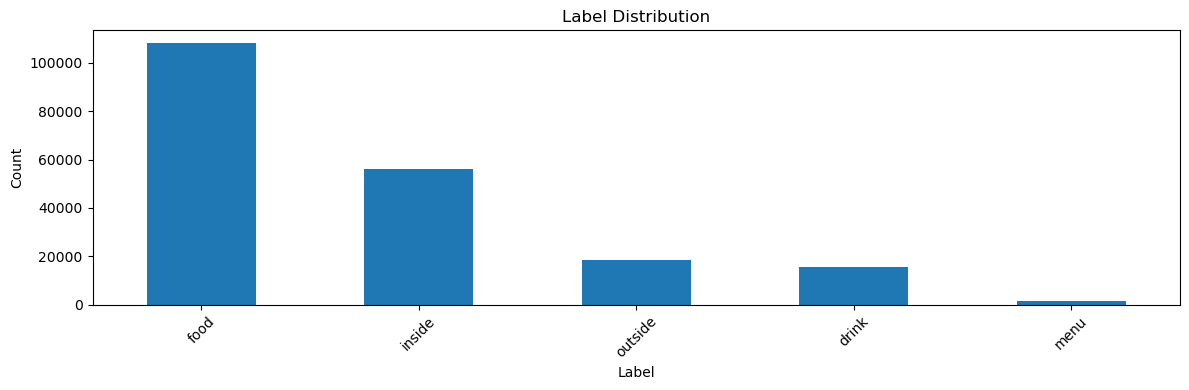

In [53]:
plt.figure(figsize=(12, 4))
clean_df['label'].value_counts().plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_label_distribution.png")
plt.show()

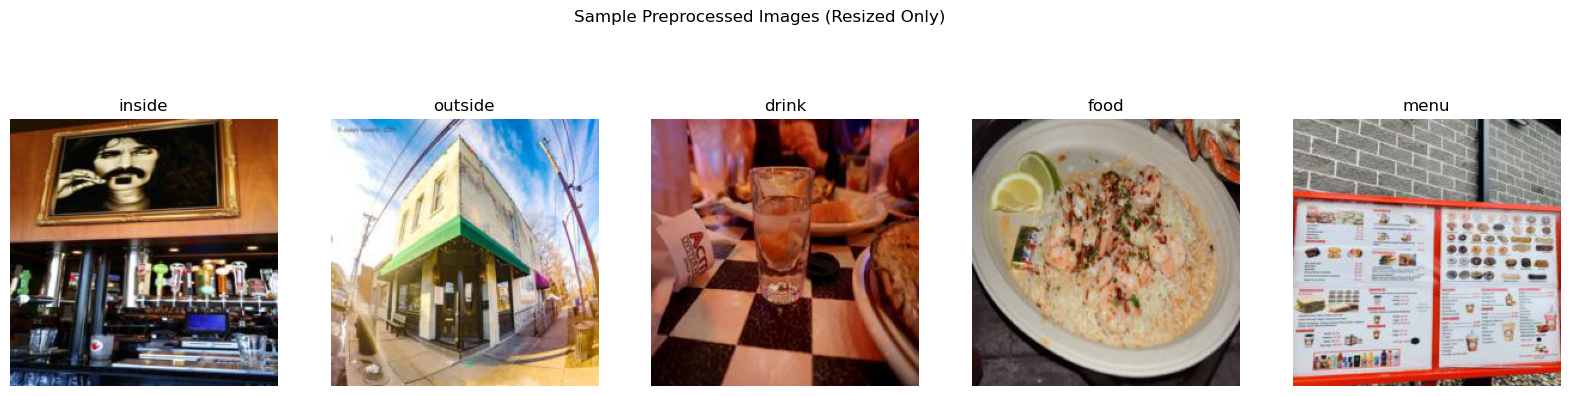

In [54]:
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for idx, label in enumerate(clean_df['label'].unique()[:5]):
    sample_path = clean_df[clean_df['label'] == label]['preprocessed_path'].values[0]
    axs[idx].imshow(Image.open(sample_path))
    axs[idx].set_title(label)
    axs[idx].axis('off')
plt.suptitle("Sample Preprocessed Images (Resized Only)")
plt.savefig("eda_sample_images.png")
plt.show()


In [55]:
class YelpPhotoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['preprocessed_path']
        label = self.df.iloc[idx]['label_encoded']
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image.to(device), torch.tensor(label).long().to(device)


In [56]:
def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.Resize(resize_shape),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize(resize_shape),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])
        ])

train_dataset = YelpPhotoDataset(train_df, transform=get_transforms(train=True))
test_dataset = YelpPhotoDataset(test_df, transform=get_transforms(train=False))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("DataLoaders ready")


DataLoaders ready
